In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv(
    "../data/processed/nav_with_returns.csv"
)

transactions = pd.read_csv(
    "../data/processed/cleaned_investor_transactions.csv"
)

fund_master = pd.read_csv(
    "../data/processed/cleaned_01_fund_master.csv"
)

holdings = pd.read_csv(
    "../data/processed/cleaned_09_portfolio_holdings.csv"
)

scorecard = pd.read_csv(
    "../reports/fund_scorecard.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print("Loaded Successfully")

Loaded Successfully


In [3]:
var_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append([
        fund,
        var95,
        cvar95
    ])

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [4]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("VaR Report Saved")

VaR Report Saved


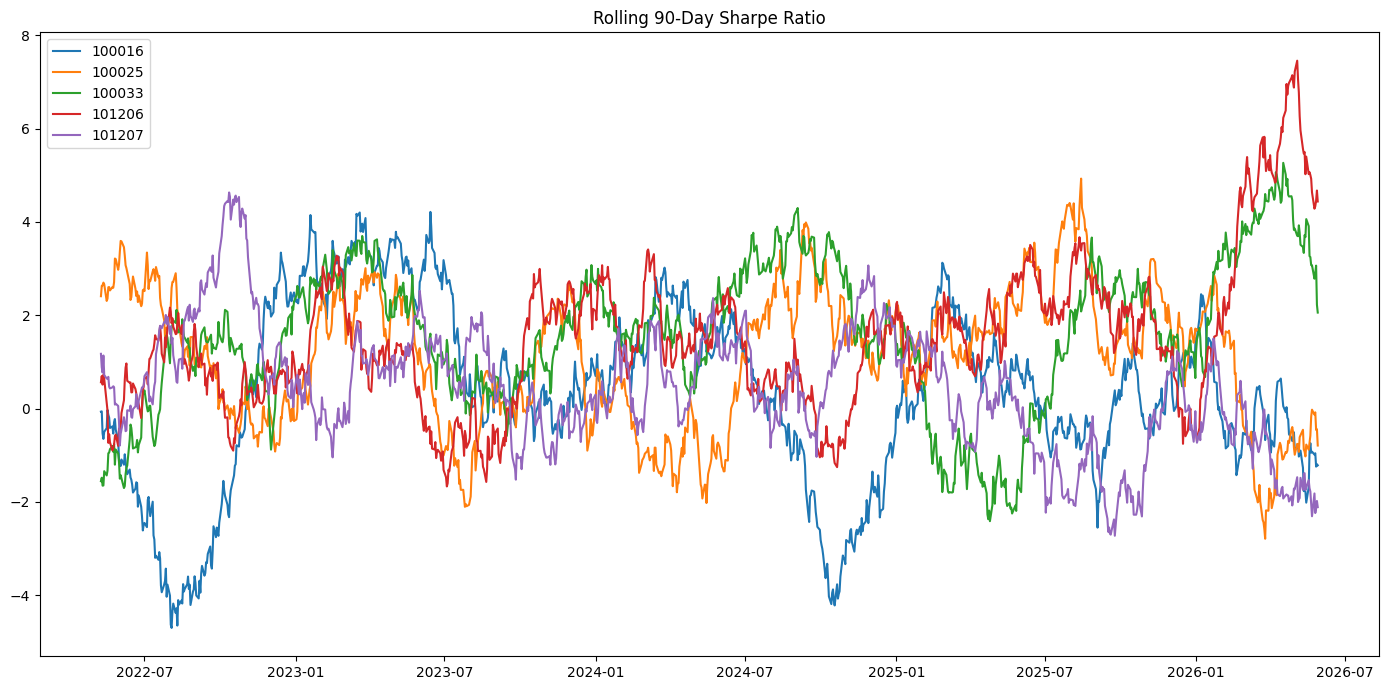

In [5]:
key_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(14,7))

for fund in key_funds:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

In [6]:
transactions["cohort_year"] = (
    transactions.groupby(
        "investor_id"
    )["transaction_date"]
    .transform("min")
    .dt.year
)

cohort_summary = (
    transactions.groupby(
        "cohort_year"
    )
    .agg(
        avg_investment=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
)

cohort_summary

,avg_investment,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [7]:
top_fund_cohort = (
    transactions.groupby(
        ["cohort_year",
         "amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_fund_cohort = (
    top_fund_cohort
    .sort_values(
        "count",
        ascending=False
    )
    .groupby("cohort_year")
    .first()
)

top_fund_cohort

,amfi_code,count
cohort_year,,
2024,148568,874
2025,119599,12


In [8]:
sip_txn = transactions[
    transactions["transaction_type"]
    == "SIP"
].copy()

sip_txn = sip_txn.sort_values(
    ["investor_id",
     "transaction_date"]
)

sip_txn["gap_days"] = (
    sip_txn.groupby(
        "investor_id"
    )["transaction_date"]
    .diff()
    .dt.days
)

sip_summary = (
    sip_txn.groupby(
        "investor_id"
    )
    .agg(
        avg_gap=(
            "gap_days",
            "mean"
        ),
        sip_count=(
            "transaction_date",
            "count"
        )
    )
)

sip_summary = sip_summary[
    sip_summary["sip_count"] >= 6
]

sip_summary["status"] = np.where(
    sip_summary["avg_gap"] > 35,
    "At Risk",
    "Healthy"
)

sip_summary.head()

,avg_gap,sip_count,status
investor_id,,,
INV000004,85.400000,6,At Risk
INV000008,70.400000,6,At Risk
INV000010,64.800000,6,At Risk
INV000011,40.166667,7,At Risk
INV000012,57.000000,8,At Risk


In [9]:
sip_summary["status"].value_counts(
    normalize=True
) * 100

status
At Risk    97.797357
Healthy     2.202643
Name: proportion, dtype: float64

In [10]:
hhi_results = []

for fund in holdings[
    "amfi_code"
].unique():

    df = holdings[
        holdings["amfi_code"]
        == fund
    ]

    hhi = (
        (
            df["weight_pct"]
            / 100
        ) ** 2
    ).sum()

    hhi_results.append(
        [fund, hhi]
    )

hhi_df = pd.DataFrame(
    hhi_results,
    columns=[
        "amfi_code",
        "HHI"
    ]
)

hhi_df.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
19,119092,0.206448
24,101207,0.200700
3,119599,0.174751
25,102885,0.174709
12,118632,0.168298


Insight 1
Funds with the highest VaR exhibit greater downside risk during volatile market periods.

Insight 2
Certain investor cohorts contribute significantly higher total investment amounts than others.


Insight 3
The majority of SIP investors maintain healthy contribution intervals below 35 days.

Insight 4
Funds with stronger rolling Sharpe ratios demonstrate more consistent risk-adjusted performance.

Insight 5
High-HHI portfolios are more concentrated and therefore carry greater sector-specific risk.